## 02. Exploratory Data Analysis: Using the Clean Data

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

data = pd.read_csv('../data/processed/sms_data_cleaned.csv')
data.sample(10)

,date,year,month,punctuation_count,word_count,text_count,carrier_Smart,carrier_Globe,carrier_DITO,carrier_Unknown,dedup_group_id,text_transformed,target
193,2024-05-23 09:23:24.644,2024,May,5,22,143,1,0,0,0,170,domestic mail returned local post office pleas...,0
266,2024-04-16 11:33:02.636,2024,April,8,23,154,0,1,0,0,234,epicwin sumali tangkilikin limitadong bonus tr...,1
82,2024-07-03 06:32:25.019,2024,July,8,25,138,1,0,0,0,67,elevate status join sbet vip moneytoken bonus ...,2
201,2024-05-18 10:25:35.135,2024,May,4,27,153,1,0,0,0,177,ph postal domestic mail arrived returned post ...,0
357,2024-03-28 14:51:41.108,2024,March,8,23,156,1,0,0,0,234,epicwin sumali tangkilikin limitadong bonus tr...,1
705,2023-10-11 19:14:34.715,2023,October,5,24,155,1,0,0,0,620,gawin iyong unang deposito moneytoken ittbet m...,2
821,2023-05-03 13:07:18.955,2023,May,7,18,111,1,0,0,0,712,real name hi sugarplay vip weekly bonuses awai...,2
602,2024-01-16 09:48:37.248,2024,January,5,18,121,1,0,0,0,527,kumita habang nanonood youtube kumita moneytok...,0
512,2024-02-22 13:47:03.746,2024,February,5,16,80,1,0,0,0,444,income mag download app maka received free jlt...,0
375,2024-03-26 01:17:04.896,2024,March,8,23,156,1,0,0,0,234,epicwin sumali tangkilikin limitadong bonus tr...,1


### Data Visualizations

C:\Users\LEI\AppData\Local\Temp\ipykernel_8996\1359464769.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(ax=axis, alpha=.8)


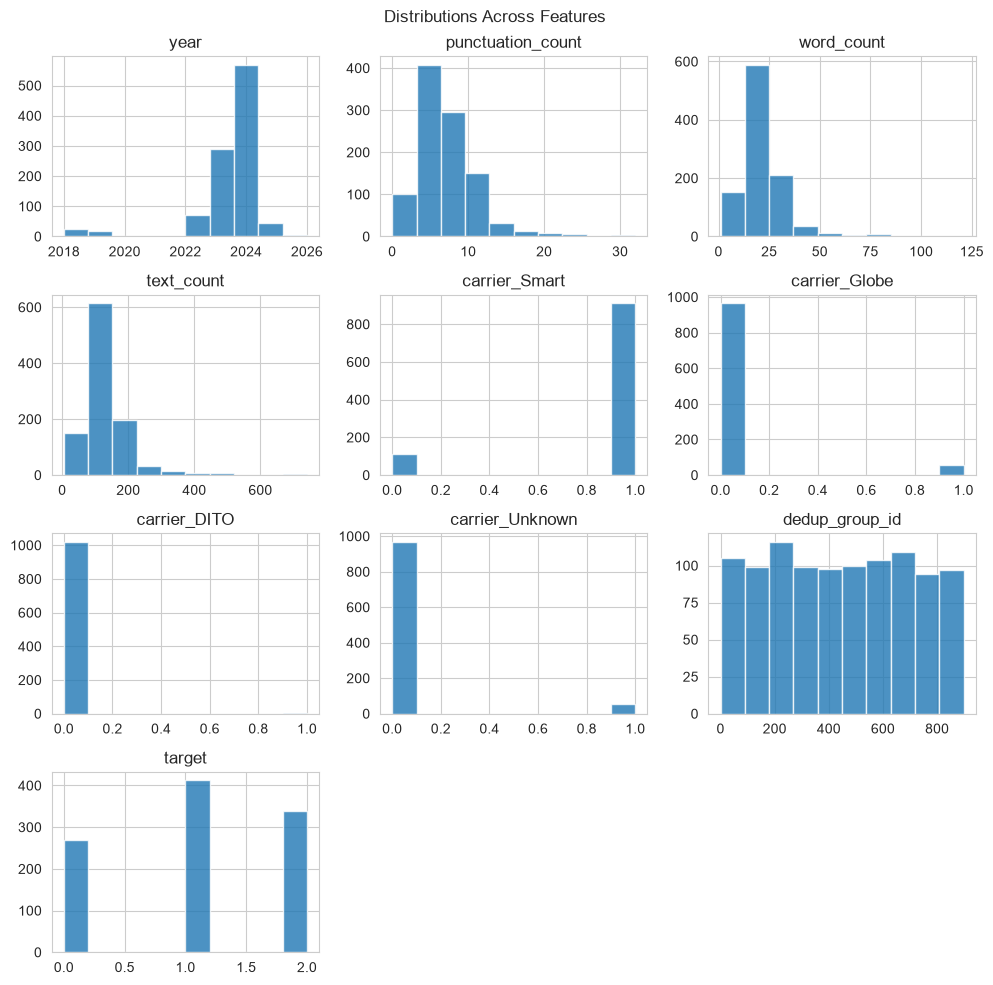

In [32]:
sns.set_style('whitegrid')
fig, axis = plt.subplots(figsize=(10, 10))

axis.set_title('Distributions Across Features')
data.hist(ax=axis, alpha=.8)
plt.suptitle('Distributions Across Features')
plt.tight_layout()


<Axes: >

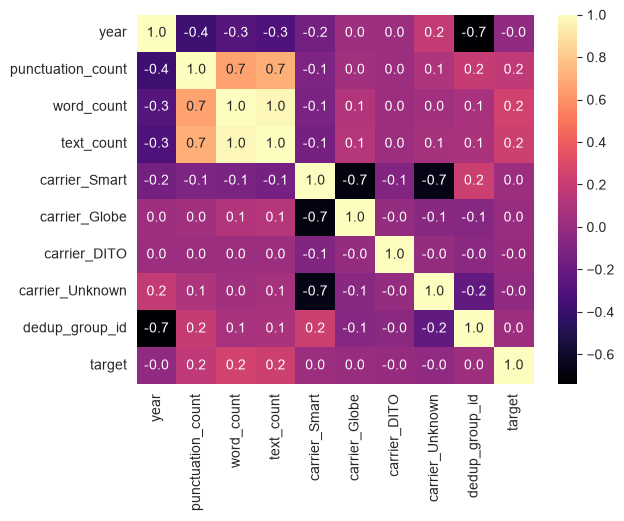

In [33]:
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.1f', cmap='magma')

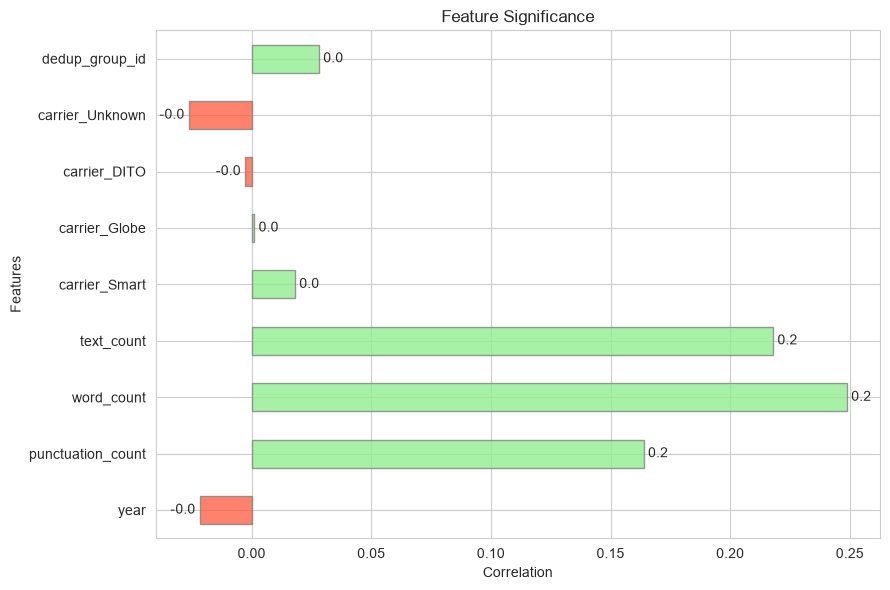

In [34]:
feat_sig = data.corr(numeric_only=True)['target'].drop('target', axis=0)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['lightgreen' if corr >= 0 else 'tomato' for corr in feat_sig]
feat_sig.plot(kind='barh', ax=ax, alpha=0.8, edgecolor='gray', color=colors)
ax.set_title('Feature Significance')
ax.set_ylabel('Features')
ax.set_xlabel('Correlation')
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)
plt.tight_layout()

target
1    412
2    339
0    270
Name: count, dtype: int64


C:\Users\LEI\AppData\Local\Temp\ipykernel_8996\772179356.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels=['Scam', 'Spam', 'Legitimate'])


Text(0.5, 0, 'Class')

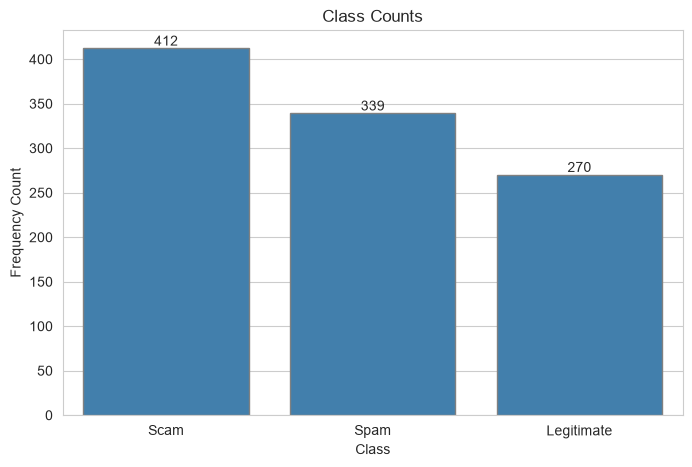

In [53]:
class_counts = data['target'].value_counts()

print(class_counts)
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=data, x='target', 
              order=class_counts.index, color='#3182bd',
              ax=ax, edgecolor='gray')
ax.bar_label(ax.containers[0])
ax.set_xticklabels(labels=['Scam', 'Spam', 'Legitimate'])
ax.set_title('Class Counts')
ax.set_ylabel('Frequency Count')
ax.set_xlabel('Class')

## Data Aggregations

        avg_word_length  avg_punctuation_ct  avg_text_count
target                                                     
0                 17.51                6.14          111.24
1                 21.11                7.47          136.14
2                 25.35                7.85          151.82


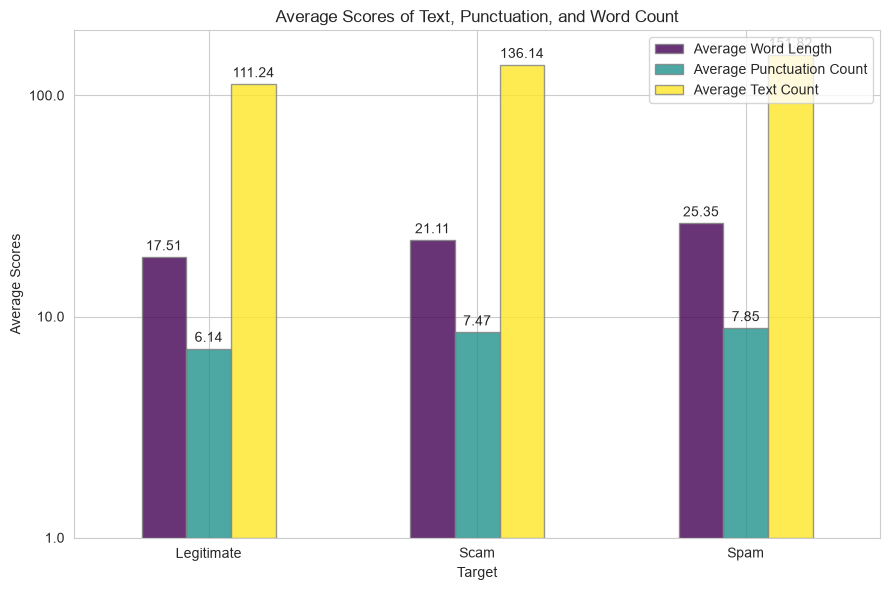

In [36]:
central_tendencies = data.groupby('target').agg(
    avg_word_length = ('word_count', 'mean'),
    avg_punctuation_ct = ('punctuation_count', 'mean'),
    avg_text_count = ('text_count', 'mean')
).round(2)

print(central_tendencies)

labels = ['Average Word Length', 'Average Punctuation Count', 'Average Text Count']
fig, ax = plt.subplots(figsize=(9, 6))
central_tendencies.plot(kind='bar', log=True, alpha=0.8, edgecolor='gray', ax=ax, cmap='viridis')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.legend(labels=labels)
ax.set_ylabel('Average Scores')
ax.set_xlabel('Target')
ax.set_xticklabels(labels=['Legitimate', 'Scam', 'Spam'], rotation=0)
ax.set_title('Average Scores of Text, Punctuation, and Word Count')
plt.tight_layout()

for values in ax.containers:
    ax.bar_label(values, padding=3)


        med_word_length  med_punctuation_ct  med_text_count
target                                                     
0                  17.0                 5.0           110.5
1                  20.0                 7.0           133.0
2                  22.0                 7.0           130.0


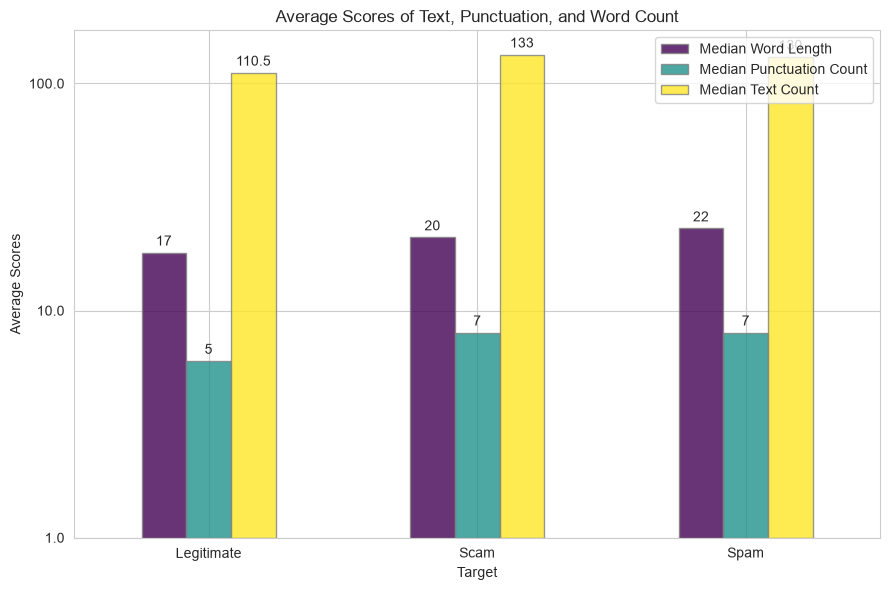

In [37]:
medians = data.groupby('target').agg(
    med_word_length = ('word_count', 'median'),
    med_punctuation_ct = ('punctuation_count', 'median'),
    med_text_count = ('text_count', 'median')
).round(2)

print(medians)

labels = ['Median Word Length', 'Median Punctuation Count', 'Median Text Count']
fig, ax = plt.subplots(figsize=(9, 6))
medians.plot(kind='bar', log=True, alpha=0.8, edgecolor='gray', ax=ax, cmap='viridis')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.legend(labels=labels)
ax.set_ylabel('Average Scores')
ax.set_xlabel('Target')
ax.set_xticklabels(labels=['Legitimate', 'Scam', 'Spam'], rotation=0)
ax.set_title('Average Scores of Text, Punctuation, and Word Count')
plt.tight_layout()

for values in ax.containers:
    ax.bar_label(values, padding=3)


## IQRs and Outlier Detection

Text(0, 0.5, 'Principal Component 2 (24.5%)')

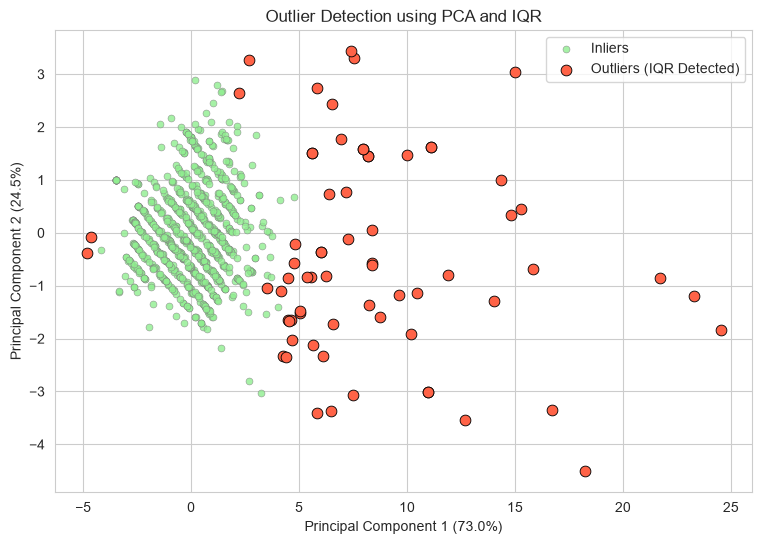

In [38]:
numericals = ['text_count', 'word_count', 'punctuation_count']

q1 = data[numericals].quantile(0.25)
q3 = data[numericals].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = data[((data[numericals] < lower_bound) | (data[numericals] > upper_bound)).any(axis=1)]

outliers = outliers[numericals]
non_outliers = data[~((data[numericals] < lower_bound) | (data[numericals] > upper_bound)).any(axis=1)]  
non_outliers = non_outliers[numericals]

scaler = StandardScaler()
scaler.fit(non_outliers[numericals])
scaled_clean = scaler.transform(non_outliers[numericals])
scaled_outliers = scaler.transform(outliers[numericals])

pca = PCA(n_components=2)
pca.fit(scaled_clean)
decomp_clean = pca.transform(scaled_clean)
decomp_outliers = pca.transform(scaled_outliers)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(x=decomp_clean[:, 0],
                y=decomp_clean[:, 1], ax=ax, alpha=0.8, c='lightgreen', edgecolor='gray',
                label='Inliers', s=25)

sns.scatterplot(x=decomp_outliers[:, 0],
                y=decomp_outliers[:, 1],
                ax=ax, c='tomato', edgecolor="black",
                label="Outliers (IQR Detected)", s=60)

ax.set_title('Outlier Detection using PCA and IQR')
ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})")